# 07 Walk Forward Out of Sample Backtest

Run the full daily strategy with frozen formation parameters, lagged next-close instructions, exact forecast horizons and a 5% equity budget per entry limited by available cash. There is no open-position count limit; only one position per pair is held. This is the only notebook that runs the main portfolio simulation.

Run cells from top to bottom, or choose **Run All** for this notebook only. Each module saves its outputs for the next notebook. Restart the kernel after pulling code changes.


## 1. Imports and saved run


In [1]:
%matplotlib inline
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'research_config.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open Jupyter inside the Pairs_trading repository.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.project_io import OUTPUT_DIR, initialize, load_config, load_frame, save_frame, save_json

cfg = load_config()


## 2. Load frozen formation data and settings

Module 04 and Module 06 previews are not fed in as a replacement for daily forecasting. The engine uses their shared functions across the complete test period.


In [2]:
from src.project_io import read_series, backtest_kwargs
from src.backtest import run_walk_forward_backtest
from src.research_validation import portfolio_metrics

train_prices = load_frame("train_prices")
test_prices = load_frame("test_prices")
eligible_pairs = load_frame("eligible_pairs")
cointegrated_pairs = load_frame("cointegrated_pairs")
risk_free_rates = read_series(OUTPUT_DIR / "inputs/rates.parquet")
display(pd.Series(backtest_kwargs(cfg)))


initial_capital            100000.00
entry_z                         1.50
target_probability              0.70
memory_window                  60.00
max_horizon_days              126.00
n_paths                      5000.00
ewma_lambda                     0.94
seed                           42.00
max_open_pairs                   NaN
premium_budget_fraction         0.05
max_hedge_error                 0.10
slippage_bps                   10.00
commission_per_contract         0.65
dtype: float64

## 3. Run the simulation

This cell may take time. Diagnostics in Modules 08–11 load the saved result and do not rerun it.


In [3]:
result = run_walk_forward_backtest(
    train_prices,
    test_prices,
    eligible_pairs,
    cointegrated_pairs,
    risk_free_rates,
    **backtest_kwargs(cfg)
)
trades = result["trades"]
equity_curve = result["equity_curve"]
summary = portfolio_metrics(result, cfg.initial_capital)
for name, frame in result.items():
    save_frame(name, frame)
save_json("backtest_summary", summary)
display(pd.Series(summary, name="Backtest results"))


initial_capital             100000.000000
final_equity                123613.815179
total_return                     0.236138
max_drawdown                    -0.594387
n_trades                       159.000000
win_rate                         0.515723
average_trade_return             0.042065
median_trade_return              0.073003
max_concurrent_positions        25.000000
daily_sharpe                     0.371287
Name: Backtest results, dtype: float64

## 4. Accounting and timing checks

These checks fail if funding, timing or cash reconciliation differs from the declared methodology.


,pair,dependent,independent,alpha,beta,mu,signal_date,signal_spread,entry_z,direction,...,exit_spread,exit_value,exit_model_value,exit_cost,exit_dependent_option_price,exit_independent_option_price,pnl,trade_return,holding_trading_days,holding_calendar_days
0,NTRS-PNC,NTRS,PNC,1.235142,0.663290,6.260168e-14,2022-12-29,-0.110887,-1.977100,-1,...,-0.063350,5831.504031,5841.245276,9.741245,7.134048,14.938130,1114.224680,0.236201,12,20
1,ABT-ZTS,ABT,ZTS,0.338157,0.841182,-7.119061e-15,2022-12-28,0.126236,2.067096,1,...,-0.041432,7320.635398,7331.867265,11.231867,3.965998,28.727341,3324.493897,0.831926,32,48
2,CDW-MSI,CDW,MSI,-0.931474,1.126032,-1.164832e-14,2022-12-28,-0.140629,-1.629882,-1,...,-0.009700,8269.722224,8280.602827,10.880603,34.579052,6.823962,3288.109778,0.660049,34,50
3,ADP-RSG,ADP,RSG,0.600596,0.982033,2.862924e-14,2023-01-11,0.103161,1.520624,1,...,-0.009585,6905.351787,6915.517305,10.165517,19.343586,10.156000,2472.565088,0.557790,26,40
4,MLM-VMC,MLM,VMC,-1.118299,1.356263,1.064567e-13,2023-02-09,-0.079384,-1.588086,-1,...,0.005031,5428.882099,5436.919018,8.036919,9.764506,14.868228,1951.099765,0.561018,19,28
5,ADP-WM,ADP,WM,0.371251,0.989720,1.714755e-15,2023-01-13,0.117567,1.961112,1,...,-0.021177,4962.495556,4970.065622,7.570066,19.854868,4.995460,890.499786,0.218689,39,56
6,HD-SHW,HD,SHW,0.624051,0.904478,1.477941e-15,2023-01-04,0.109133,2.107410,1,...,0.108713,1663.851929,1663.851929,0.000000,16.638519,0.000000,-830.983036,-0.333081,59,85
7,AEP-ETR,AEP,ETR,1.069609,0.851364,-3.098728e-14,2023-01-03,0.053340,1.614854,1,...,0.026498,2655.688477,2655.688477,0.000000,3.319611,0.000000,-2240.288376,-0.457577,61,89
8,ABT-ZTS,ABT,ZTS,0.338157,0.841182,-7.119061e-15,2023-03-09,-0.096446,-1.579281,-1,...,-0.007051,7593.535913,7606.342256,12.806342,14.800974,0.686184,2921.158461,0.625197,28,41
9,AMAT-MCHP,AMAT,MCHP,-1.701490,1.522630,8.993879e-15,2023-02-03,-0.183439,-1.542284,-1,...,-0.009206,3399.280424,3405.285709,6.005286,3.285416,10.255814,-91.099000,-0.026100,57,81


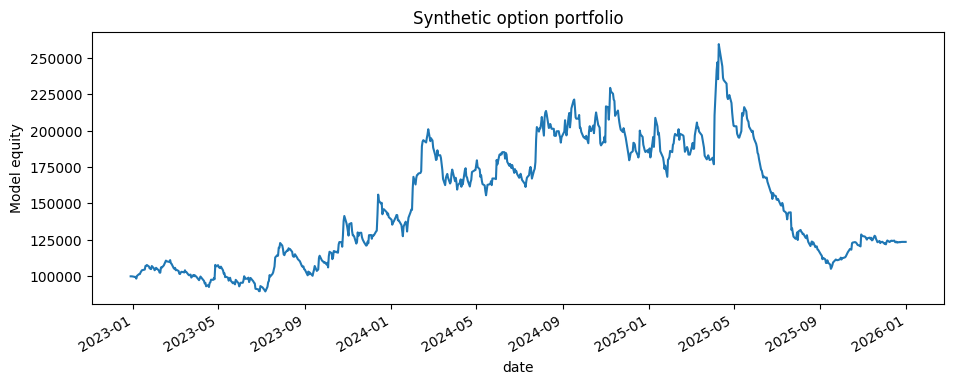

In [4]:
assert equity_curve.cash.min() >= -1e-7
assert (
    cfg.max_open_pairs is None
    or equity_curve.n_open_positions.max() <= cfg.max_open_pairs
)
assert np.allclose(
    equity_curve.equity, equity_curve.cash + equity_curve.open_position_value
)
assert np.isclose(equity_curve.equity.iloc[-1], cfg.initial_capital + trades.pnl.sum())
if not trades.empty:
    assert (trades.entry_date > trades.signal_date).all()
    assert (trades.entry_premium <= trades.entry_budget + 1e-7).all()
display(trades.head(10))
equity_curve.equity.plot(figsize=(11, 4), title="Synthetic option portfolio")
plt.ylabel("Model equity")
plt.show()


## Save module completion

Wait for this confirmation before moving to the next notebook.


In [5]:
print(f"Completed. Files saved in {OUTPUT_DIR}")


Completed. Files saved in /home/runner/work/Pairs_trading/Pairs_trading/data/processed/current
